# Testing qipQST

## Imports

In [2]:
import numpy as np

import h5py
import json

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec

plt.style.use('dark_background')
# plt.style.use('default')

## Ramsey Plot

In [ ]:
f = h5py.File("ramsey_results.h5")
results = f["results"]
parameters = f["parameters"]

assert(isinstance(results, h5py.Group))
assert(isinstance(parameters, h5py.Group))

guess_larmors = parameters["qubits_larmor_base_value"]
taus = parameters["circuit_Idle_duration"]
results = results["probabilities"]

In [ ]:
assert(isinstance(results, h5py.Dataset))
assert(isinstance(guess_larmors, h5py.Dataset))
assert(isinstance(taus, h5py.Dataset))

X, Y = np.meshgrid(guess_larmors, taus)
pcolorm = plt.pcolormesh(X, Y, results, shading="nearest", cmap="magma")
# pcolorm = plt.pcolormesh(X, Y, results, shading="gouraud", cmap="magma")
plt.colorbar(pcolorm)
plt.ylabel("Tau")
plt.xlabel("Guess")
plt.title("")
plt.show()

tau_index = 50
plt.plot(guess_larmors[:], results[tau_index])
plt.title("Slide at $\\tau = {}$".format(taus[tau_index]))
plt.ylabel("Probability")
plt.xlabel("Guess")
plt.show()

In [10]:
f.close()

## ATM

### Parameters

In [11]:
# Get params from config
with open("atm_config.json", "r") as file:
    data_labels = json.load(file)
atm_params = data_labels["circuit"]["gates"]["ATMGate"]

# Pulse Parameters
pulse_time = atm_params["duration"]  # (us) Total time of the pulse
rise_time = atm_params["rise_time"]  # (us) Amount of time the pulse takes to rise to the maximum amplitude
fall_time = atm_params["fall_time"]  # (us) Amount of time the pulse takes to fall to 0 amplitude
max_amplitude = atm_params["max_amplitude"]  # (MHZ) Maximum amplitude the pulse will rise too (This should usually be the rabi frequency)
max_frequency = atm_params["max_frequency"] # (MHz) Maximum frequency offset the pulse will start at
percent_rise_gradient = atm_params["rise_gradient"] # Inital slope of the rising amplitude of the pulse
percent_fall_gradient = atm_params["fall_gradient"] # Ending slope of the falling amplitude

### Results

In [12]:
f = h5py.File("atm_results.h5")
results = f["results"]
parameters = f["parameters"]
waveform = f["waveform"]

print("Result Groups:")
for key in results:
    print("| ", key)

print("----------------------")

print("Parameter Groups:")
for key in parameters:
    print("| ", key)


assert(isinstance(parameters, h5py.Group))
detunings = np.array(parameters["qubits_guess_larmor"])

detuning = -0.25
detuning_index = np.abs(detunings - detuning).argmin()

assert(isinstance(results, h5py.Group))
probabilities = np.array(results["probabilities"])
times = np.array(results["times"])
bloch_coords = results["bloch_coords"]

assert(isinstance(bloch_coords, h5py.Group))
x_coords = np.array(bloch_coords["x_coords"][detuning_index,:])
y_coords = np.array(bloch_coords["y_coords"][detuning_index,:])
z_coords = np.array(bloch_coords["z_coords"][detuning_index,:])

rise_index = np.abs(times - rise_time).argmin()
mid_index = np.abs(times - (pulse_time - rise_time - fall_time)).argmin()

Result Groups:
|  adiabaticity
|  bloch_coords
|  durations
|  eigenenergies
|  eigenstates
|  hamiltonians
|  probabilities
|  times
----------------------
Parameter Groups:
|  qubits_guess_larmor


In [13]:
print(np.shape(np.array(results["eigenstates"])))
print(np.shape(np.array(results["eigenenergies"])))

(250, 1000, 2, 2)
(250, 1000, 2)


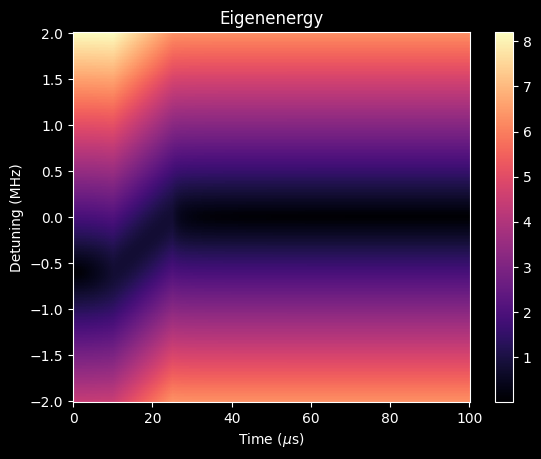

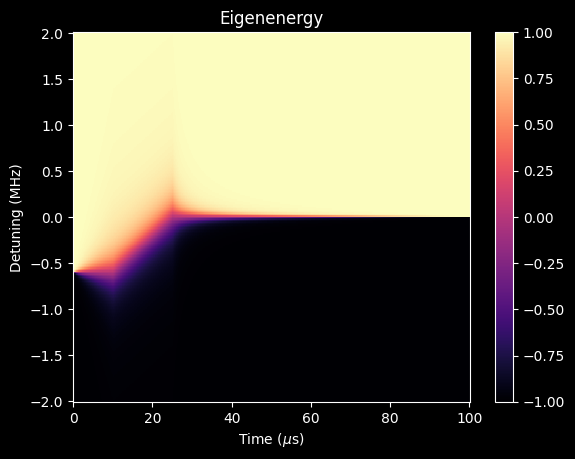

In [14]:
X, Y = np.meshgrid(times[0], detunings)
pcolorm = plt.pcolormesh(X, Y, np.array(results["eigenenergies"])[:,:,1], shading="nearest", cmap="magma")
plt.colorbar(pcolorm)
plt.ylabel("Detuning (MHz)")
plt.xlabel("Time ($\\mu$s)")
plt.title("Eigenenergy")
plt.show()

eigenstates = np.zeros((len(detunings), 1000))

for i in range(len(detunings)):
    for j in range(1000):
        # eigenstates[i][j] = np.array(results["eigenstates"][i,j,0,:]).dot(np.conjugate(results["eigenstates"][i,j,0,:])).real
        eigenstates[i][j] = np.conjugate(np.array(results["eigenstates"][i,j,0,:])).dot(np.array([[1, 0], [0, -1]]).dot(np.array(results["eigenstates"][i,j,0,:]))).real
        #print(results["eigenstates"][i,j,0,:])
        # eigenstates[i][j] = results["eigenstates"][i,j,0,0].real
        #print(np.linalg.eigh(results["hamiltonians"][i,j,:,:]))
        #print(i, j)
        #print(results["eigenstates"][i,j,:,:])

X, Y = np.meshgrid(times[0], detunings)
pcolorm = plt.pcolormesh(X, Y, eigenstates, shading="nearest", cmap="magma")
plt.colorbar(pcolorm)
plt.ylabel("Detuning (MHz)")
plt.xlabel("Time ($\\mu$s)")
plt.title("Eigenenergy")
plt.show()

###  Waveform

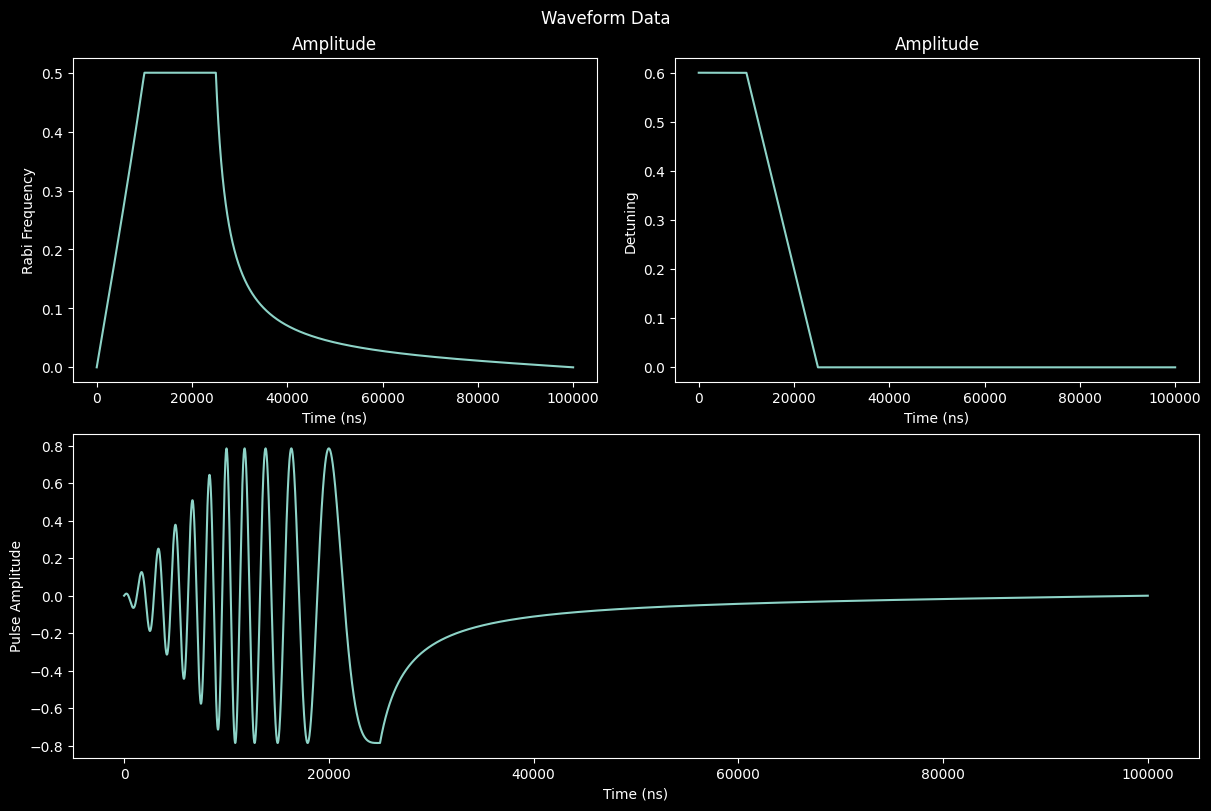

In [15]:
assert(isinstance(waveform, h5py.Group))

fig = plt.figure(layout = "constrained", figsize = (12, 8))

gs = GridSpec(2, 2, figure = fig)

amp_ax = fig.add_subplot(gs[0, 0])
freq_ax = fig.add_subplot(gs[0, 1])
pulse_ax = fig.add_subplot(gs[1, :])

fig.suptitle("Waveform Data")

amp_ax.plot(np.array(waveform["amplitude"]))
amp_ax.set_title("Amplitude")
amp_ax.set_ylabel("Rabi Frequency")
amp_ax.set_xlabel("Time (ns)")


freq_ax.plot(np.array(waveform["frequency"]))
freq_ax.set_title("Amplitude")
freq_ax.set_ylabel("Detuning")
freq_ax.set_xlabel("Time (ns)")

pulse_ax.plot(np.array(waveform["pulse_iq"])[0,:])
pulse_ax.set_ylabel("Pulse Amplitude")
pulse_ax.set_xlabel("Time (ns)")

plt.show()

### Detuning Response

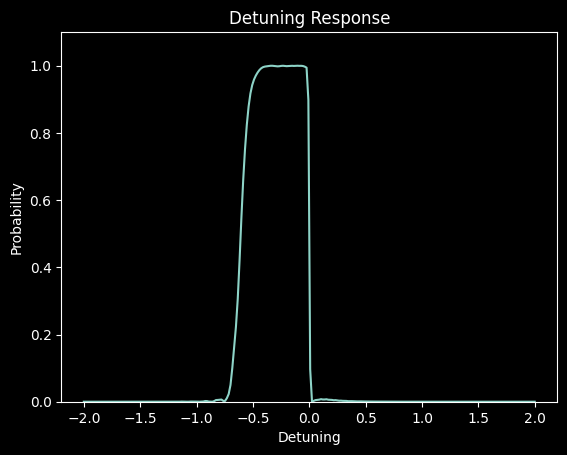

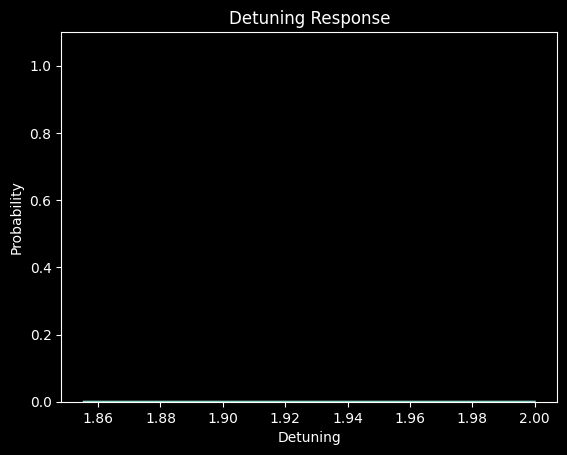

In [16]:
plt.plot(detunings[:], probabilities[:,-1])
plt.ylim(0, 1.1)
plt.title("Detuning Response")
plt.ylabel("Probability")
plt.xlabel("Detuning")
plt.show()

plt.plot(detunings[240:260], probabilities[240:260,-1])
plt.ylim(0, 1.1)
plt.title("Detuning Response")
plt.ylabel("Probability")
plt.xlabel("Detuning")
plt.show()

### Time Evolution

#### All Detunings

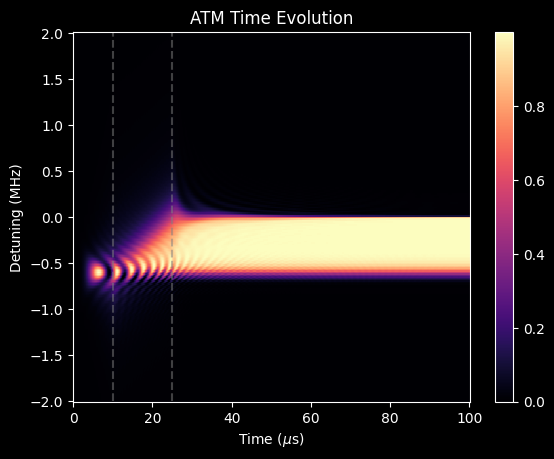

In [17]:
X, Y = np.meshgrid(times[0], detunings)
pcolorm = plt.pcolormesh(X, Y, probabilities, shading="nearest", cmap="magma")
plt.colorbar(pcolorm)
plt.ylabel("Detuning (MHz)")
plt.xlabel("Time ($\\mu$s)")
plt.title("ATM Time Evolution")
plt.vlines(rise_time, min(detunings), max(detunings), color = "grey", alpha = 0.5, ls = "--")
plt.vlines(pulse_time - fall_time, min(detunings), max(detunings), color = "grey", alpha = 0.5, ls = "--")
plt.show()

#### Single Detuning

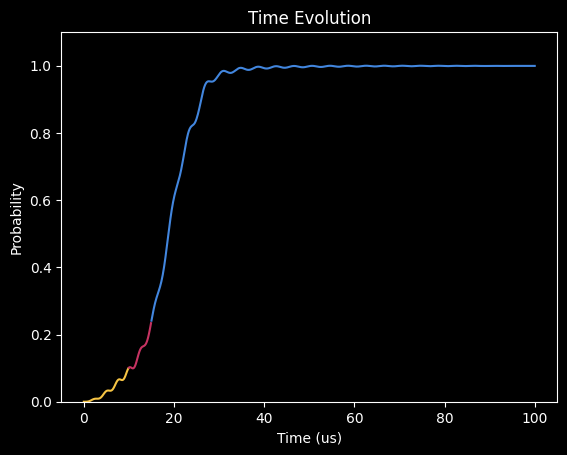

In [18]:
plt.plot(times[detuning_index][:rise_index], probabilities[detuning_index][:rise_index], color = "#f6c444")
plt.plot(times[detuning_index][rise_index:mid_index], probabilities[detuning_index][rise_index:mid_index], color = "#c63362")
plt.plot(times[detuning_index][mid_index:], probabilities[detuning_index][mid_index:], color = "#4286de")
plt.ylim(0, 1.1)
plt.title("Time Evolution")
plt.ylabel("Probability")
plt.xlabel("Time (us)")
plt.show()

#### Bloch Sphere

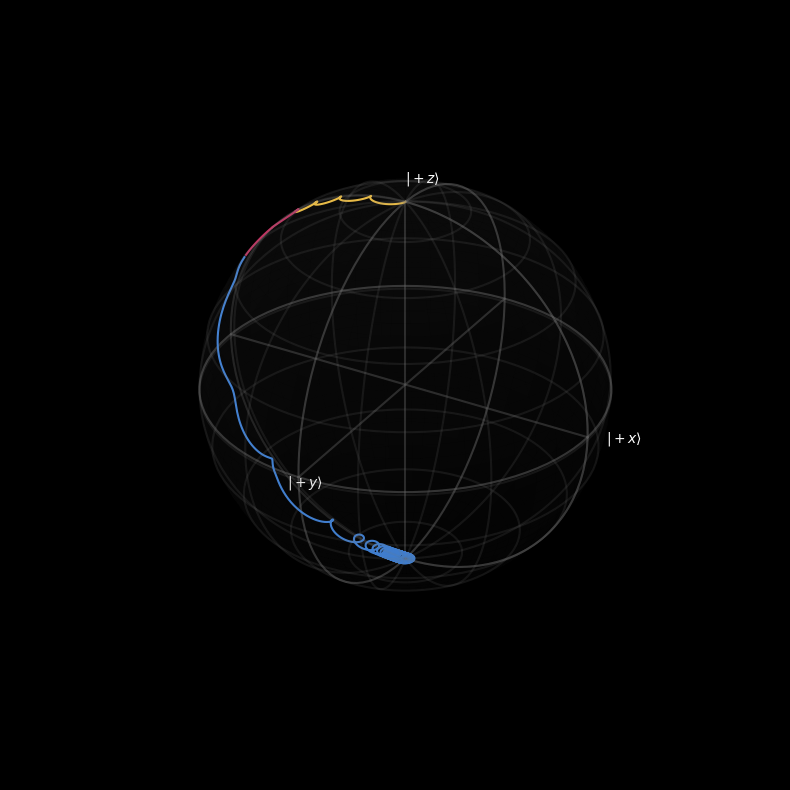

In [19]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1,1,1, projection='3d')
ax.invert_yaxis()
ax.set_axis_off()

# Make data
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))

# Plot a basic wireframe.
ax.plot_wireframe(x, y, z, rstride=10, cstride=10, color='grey', alpha = 0.15)

# Plot the surface
ax.plot_surface(x, y, z, alpha=0.05, color = 'grey')

# Prepare arrays x, y, z
wireAngles = np.linspace(0, 2 * np.pi, 100)

x = np.cos(wireAngles)
y = np.sin(wireAngles)
z = np.zeros(np.shape(x))
ax.plot(x, y, z, color = 'dimgray', alpha = 0.5)

x = np.cos(wireAngles)
y = np.zeros(np.shape(x))
z = np.sin(wireAngles)
ax.plot(x, y, z, color = 'dimgray', alpha = 0.3)

x = np.zeros(np.shape(y))
y = np.cos(wireAngles)
z = np.sin(wireAngles)
ax.plot(x, y, z, color = 'dimgray', alpha = 0.5)


ax.plot([-1, 1], [0, 0], [0, 0], color = 'dimgray', alpha = 0.4)
ax.plot([0, 0], [-1, 1], [0, 0], color = 'dimgray', alpha = 0.4)
ax.plot([0, 0], [0, 0], [-1, 1], color = 'dimgray', alpha = 0.4)

ax.text(0, 0, 1.1, "$|+z\\rangle$")
ax.text(0, 1.1, 0, "$|+y\\rangle$")
ax.text(1.1, 0, 0, "$|+x\\rangle$")

#for i in range(len(x_coords) - 1):
#    ax.plot(x_coords[i:i+2], y_coords[i:i+2], z_coords[i:i+2], color=mpl.colormaps['jet'](i/len(x_coords)))

ax.plot(x_coords[:rise_index], y_coords[:rise_index], z_coords[:rise_index], color = "#f6c444")
ax.plot(x_coords[rise_index:mid_index], y_coords[rise_index:mid_index], z_coords[rise_index:mid_index], color = "#c63362")
ax.plot(x_coords[mid_index:], y_coords[mid_index:], z_coords[mid_index:], color = "#4286de")

# Set an equal aspect ratio
ax.set_aspect('equal')

plt.show()

In [20]:
f.close()

## Larmor Plot

In [ ]:
f = h5py.File("larmor_data.h5")
larmor_values = f["larmor_data"]
time_values = f["time_data"]

In [ ]:
assert(isinstance(larmor_values, h5py.Dataset))
assert(isinstance(time_values, h5py.Dataset))

fig, ax = plt.subplots(figsize = (20, 5))
ax.plot(time_values[:], larmor_values[:])
plt.show()

In [ ]:
f.close()

## Rabi Plot

In [ ]:
f = h5py.File("rabi_results.h5")
results = f["results"]
parameters = f["parameters"]

In [ ]:
assert(isinstance(results, h5py.Group))

bloch_coords = results["bloch_coords"]
assert(isinstance(bloch_coords, h5py.Group))

x_coords = bloch_coords["x_coords"]
y_coords = bloch_coords["y_coords"]
z_coords = bloch_coords["z_coords"]

probabilities = results["probabilities"]

assert(isinstance(probabilities, h5py.Dataset))
durations = np.linspace(0, 10, len(probabilities))

In [ ]:
assert(isinstance(probabilities, h5py.Dataset))

fig, ax = plt.subplots(figsize = (20, 5))
ax.plot(durations[:], probabilities[:])
plt.show()

In [ ]:
assert(isinstance(x_coords, h5py.Dataset))
assert(isinstance(y_coords, h5py.Dataset))
assert(isinstance(z_coords, h5py.Dataset))

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1,1,1, projection='3d')
ax.invert_yaxis()
ax.set_axis_off()

# Make data
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))

# Plot a basic wireframe.
ax.plot_wireframe(x, y, z, rstride=10, cstride=10, color='grey', alpha = 0.15)

# Plot the surface
ax.plot_surface(x, y, z, alpha=0.05, color = 'grey')

# Prepare arrays x, y, z
wireAngles = np.linspace(0, 2 * np.pi, 100)

x = np.cos(wireAngles)
y = np.sin(wireAngles)
z = np.zeros(np.shape(x))
ax.plot(x, y, z, color = 'dimgray', alpha = 0.5)

x = np.cos(wireAngles)
y = np.zeros(np.shape(x))
z = np.sin(wireAngles)
ax.plot(x, y, z, color = 'dimgray', alpha = 0.3)

x = np.zeros(np.shape(y))
y = np.cos(wireAngles)
z = np.sin(wireAngles)
ax.plot(x, y, z, color = 'dimgray', alpha = 0.5)


ax.plot([-1, 1], [0, 0], [0, 0], color = 'dimgray', alpha = 0.4)
ax.plot([0, 0], [-1, 1], [0, 0], color = 'dimgray', alpha = 0.4)
ax.plot([0, 0], [0, 0], [-1, 1], color = 'dimgray', alpha = 0.4)

ax.text(0, 0, 1.1, "$|+z\\rangle$")
ax.text(0, 1.1, 0, "$|+y\\rangle$")
ax.text(1.1, 0, 0, "$|+x\\rangle$")

# ax.plot(x, y, z)

for i in range(len(x_coords) - 1):
    ax.plot(x_coords[i:i+2], y_coords[i:i+2], z_coords[i:i+2], color=mpl.colormaps['jet'](i/len(x_coords)))


# Set an equal aspect ratio
ax.set_aspect('equal')

plt.show()

In [ ]:
f.close()

## Hahn Plot

In [ ]:
f = h5py.File("hahn_results.h5")
results = f["results"]
parameters = f["parameters"]

In [ ]:
assert(isinstance(results, h5py.Group))
assert(isinstance(parameters, h5py.Group))

probabilities = results["probabilities"]
taus = parameters["circuit_Idle_duration"]

In [ ]:
assert(isinstance(probabilities, h5py.Dataset))
assert(isinstance(taus, h5py.Dataset))

fig, ax = plt.subplots(figsize = (6, 6))
ax.plot(taus[:], probabilities[:])
ax.set_ylabel("Probability")
ax.set_xlabel("Tau")
ax.set_ylim(0, 1)
plt.show()

In [ ]:
f.close()

## T2 Plot

In [ ]:
f = h5py.File("T2_relaxation.h5")
results = f["results"]
parameters = f["parameters"]

In [ ]:
assert(isinstance(results, h5py.Group))
assert(isinstance(parameters, h5py.Group))
probabilities = results["probabilities"]
taus = parameters["circuit_Idle_duration"]

In [ ]:
assert(isinstance(probabilities, h5py.Dataset))
assert(isinstance(taus, h5py.Dataset))

fig, ax = plt.subplots(figsize = (6, 6))
ax.plot(taus[:], probabilities[:])
ax.set_ylabel("Probability")
ax.set_xlabel("Tau")
ax.set_ylim(0, 1)
plt.show()

In [ ]:
f.close()

## Test Plot

In [ ]:
f = h5py.File("test_results.h5")
results = f["results"]
parameters = f["parameters"]

In [ ]:
assert(isinstance(results, h5py.Group))

bloch_coords = results["bloch_coords"]
assert(isinstance(bloch_coords, h5py.Group))

x_coords = bloch_coords["x_coords"]
y_coords = bloch_coords["y_coords"]
z_coords = bloch_coords["z_coords"]

probabilities = results["probabilities"]

assert(isinstance(x_coords, h5py.Dataset))
assert(isinstance(y_coords, h5py.Dataset))
assert(isinstance(z_coords, h5py.Dataset))
print(x_coords.len())
print(y_coords.len())
print(z_coords.len())

In [ ]:
assert(isinstance(x_coords, h5py.Dataset))
assert(isinstance(y_coords, h5py.Dataset))
assert(isinstance(z_coords, h5py.Dataset))

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1,1,1, projection='3d')
ax.invert_yaxis()
ax.set_axis_off()

# Make data
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))

# Plot a basic wireframe.
ax.plot_wireframe(x, y, z, rstride=10, cstride=10, color='grey', alpha = 0.15)

# Plot the surface
ax.plot_surface(x, y, z, alpha=0.05, color = 'grey')

# Prepare arrays x, y, z
wireAngles = np.linspace(0, 2 * np.pi, 100)

x = np.cos(wireAngles)
y = np.sin(wireAngles)
z = np.zeros(np.shape(x))
ax.plot(x, y, z, color = 'dimgray', alpha = 0.5)

x = np.cos(wireAngles)
y = np.zeros(np.shape(x))
z = np.sin(wireAngles)
ax.plot(x, y, z, color = 'dimgray', alpha = 0.3)

x = np.zeros(np.shape(y))
y = np.cos(wireAngles)
z = np.sin(wireAngles)
ax.plot(x, y, z, color = 'dimgray', alpha = 0.5)


ax.plot([-1, 1], [0, 0], [0, 0], color = 'dimgray', alpha = 0.4)
ax.plot([0, 0], [-1, 1], [0, 0], color = 'dimgray', alpha = 0.4)
ax.plot([0, 0], [0, 0], [-1, 1], color = 'dimgray', alpha = 0.4)

ax.text(0, 0, 1.1, "$|+z\\rangle$")
ax.text(0, 1.1, 0, "$|+y\\rangle$")
ax.text(1.1, 0, 0, "$|+x\\rangle$")

# ax.plot(x, y, z)
    
for i in range(len(x_coords) - 1):
    ax.plot(x_coords[i:i+2], y_coords[i:i+2], z_coords[i:i+2], color=mpl.colormaps['jet'](i/len(x_coords)))


# Set an equal aspect ratio
ax.set_aspect('equal')

plt.show()

In [ ]:
f.close()